In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 1.35GB/s]


In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
import os

for root, dirs, files in os.walk("CWRU_Dataset"):
    for file in files:
        if file.endswith(".mat") or file.endswith(".npz") or file.endswith(".csv"):
            print(os.path.join(root, file))


CWRU_Dataset/feature_time_48k_2048_load_1.csv
CWRU_Dataset/CWRU_48k_load_1_CNN_data.npz
CWRU_Dataset/raw/IR007_1_110.mat
CWRU_Dataset/raw/B021_1_227.mat
CWRU_Dataset/raw/IR014_1_175.mat
CWRU_Dataset/raw/OR021_6_1_239.mat
CWRU_Dataset/raw/OR014_6_1_202.mat
CWRU_Dataset/raw/B014_1_190.mat
CWRU_Dataset/raw/IR021_1_214.mat
CWRU_Dataset/raw/Time_Normal_1_098.mat
CWRU_Dataset/raw/OR007_6_1_136.mat
CWRU_Dataset/raw/B007_1_123.mat


In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from scipy.signal import spectrogram

In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))

Total .mat files: 10


In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)

    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()

    raise ValueError(f"No DE_time signal found in {file_path}")


In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    for i in range(0, len(signal) - segment_size, segment_size):
        segments.append(signal[i:i+segment_size])
    return np.array(segments)

In [ ]:
import tensorflow as tf
from scipy.signal import spectrogram
import numpy as np

IMG_SIZE = 128   # you can use 64 also

def signal_to_spectrogram(segment, fs=12000, nperseg=256, noverlap=128):
    f, t, Sxx = spectrogram(segment, fs=fs, nperseg=nperseg, noverlap=noverlap)

    Sxx = np.log(Sxx + 1e-10)

    # Normalize (0 to 1)
    Sxx = (Sxx - Sxx.min()) / (Sxx.max() - Sxx.min() + 1e-10)

    # Resize to fixed image size
    Sxx = tf.image.resize(Sxx[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy()

    return Sxx


In [ ]:
X = []
y = []

SEGMENT_SIZE = 2048

for file in mat_files:
    signal = extract_signal_from_mat(file)
    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal, SEGMENT_SIZE)

    for seg in segments:
        spec_img = signal_to_spectrogram(seg)
        X.append(spec_img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Spectrogram Dataset Shape:", X.shape)   # (samples, height, width)
print("Labels Shape:", y.shape)
print("Classes:", np.unique(y))


Spectrogram Dataset Shape: (2369, 128, 128, 1)
Labels Shape: (2369,)
Classes: ['B' 'IR' 'Normal' 'OR']


In [ ]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (samples, 128, 128, 1)


X shape: (2369, 128, 128, 1)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class labels:", label_encoder.classes_)



Class labels: ['B' 'IR' 'Normal' 'OR']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (1895, 128, 128, 1)
Test : (474, 128, 128, 1)


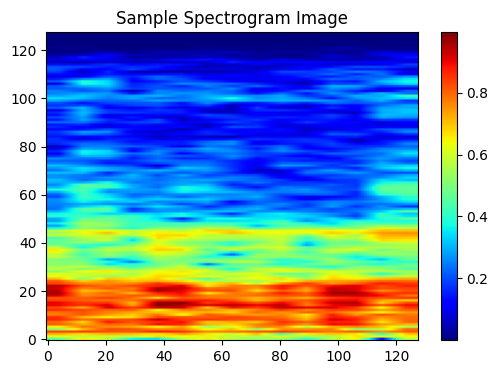

In [ ]:
plt.figure(figsize=(6,4))
plt.imshow(X[0].squeeze(), aspect='auto', origin='lower', cmap='jet')
plt.title("Sample Spectrogram Image")
plt.colorbar()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_2d = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(len(label_encoder.classes_), activation='softmax')
])

model_2d.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2d.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,516 (16.36 MB)

 Trainable params: 4,288,068 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = model_2d.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6232 - loss: 1.5497 - val_accuracy: 0.3166 - val_loss: 1.5135
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9798 - loss: 0.0692 - val_accuracy: 0.3166 - val_loss: 2.3956
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9939 - loss: 0.0296 - val_accuracy: 0.3166 - val_loss: 3.3204
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 0.3166 - val_loss: 4.2424
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9999 - loss: 0.0111 - val_accuracy: 0.3166 - val_loss: 4.7948
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9992 - loss: 0.0071 - val_accuracy: 0.3166 - val_loss: 5.0955
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.3166 - val_loss: 5.3108
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.3166 - val_lo

In [ ]:
test_loss, test_acc = model_2d.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.8625 - loss: 0.3461
Test Accuracy: 0.8586497902870178


In [ ]:
y_pred_probs = model_2d.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))


15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 428ms/step
              precision    recall  f1-score   support

           B       1.00      0.53      0.69       142
          IR       0.99      1.00      1.00       142
      Normal       1.00      1.00      1.00        47
          OR       0.68      1.00      0.81       143

    accuracy                           0.86       474
   macro avg       0.92      0.88      0.88       474
weighted avg       0.90      0.86      0.85       474



<Figure size 700x600 with 0 Axes>

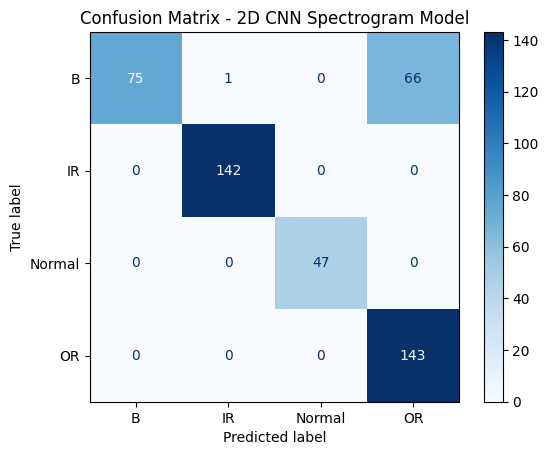

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - 2D CNN Spectrogram Model")
plt.show()

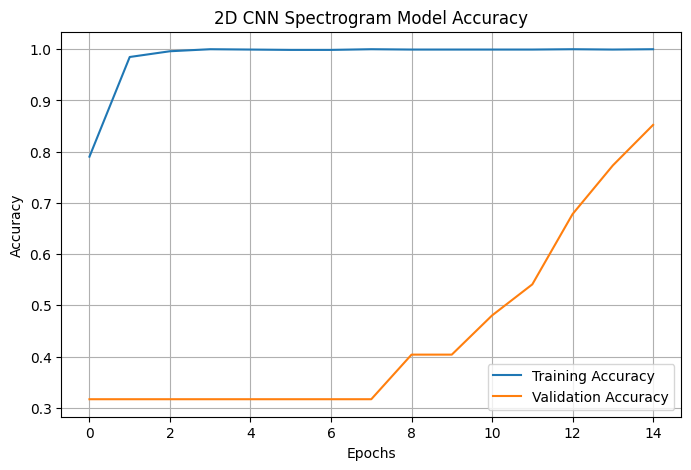

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("2D CNN Spectrogram Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_2d.save("CWRU_2D_CNN_Spectrogram_Model.keras")
print("2D CNN model saved successfully!")

2D CNN model saved successfully!
